In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.model_selection 
import sklearn.linear_model 
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler , OrdinalEncoder
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from imblearn.over_sampling import SMOTE
from tensorflow.keras import layers , models


# ***1. Read & Explore Data***

In [32]:
train = pd.read_csv('customer_churn_dataset-training-master - customer_churn_dataset-training-master.csv')
test = pd.read_csv('customer_churn_dataset-testing-master - customer_churn_dataset-testing-master.csv') 

train.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [33]:
test.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [34]:
print(f"Train Dataset Shape: {train.shape}")
print(f"Test Dataset Shape: {test.shape}")

Train Dataset Shape: (440833, 12)
Test Dataset Shape: (64374, 12)


In [35]:
print(f"Train Data Columns: {train.columns}",'\n==========================\n',f"Test Data Columns: {test.columns}")

Train Data Columns: Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object') 
 Test Data Columns: Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')


In [36]:
train=train.drop('CustomerID',axis=1)
test=test.drop(['CustomerID','Churn'],axis=1)

In [37]:
print(f"Train Data Columns: {train.columns}",'\n==========================\n',f"Test Data Columns: {test.columns}")

Train Data Columns: Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='object') 
 Test Data Columns: Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction'],
      dtype='object')


In [38]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                440832 non-null  float64
 1   Gender             440832 non-null  object 
 2   Tenure             440832 non-null  float64
 3   Usage Frequency    440832 non-null  float64
 4   Support Calls      440832 non-null  float64
 5   Payment Delay      440832 non-null  float64
 6   Subscription Type  440832 non-null  object 
 7   Contract Length    440832 non-null  object 
 8   Total Spend        440832 non-null  float64
 9   Last Interaction   440832 non-null  float64
 10  Churn              440832 non-null  float64
dtypes: float64(8), object(3)
memory usage: 37.0+ MB


In [39]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                64374 non-null  int64 
 1   Gender             64374 non-null  object
 2   Tenure             64374 non-null  int64 
 3   Usage Frequency    64374 non-null  int64 
 4   Support Calls      64374 non-null  int64 
 5   Payment Delay      64374 non-null  int64 
 6   Subscription Type  64374 non-null  object
 7   Contract Length    64374 non-null  object
 8   Total Spend        64374 non-null  int64 
 9   Last Interaction   64374 non-null  int64 
dtypes: int64(7), object(3)
memory usage: 4.9+ MB


In [40]:
train.describe()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [41]:
test.describe()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850
std,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000
25%,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000
50%,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000
75%,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000


In [42]:
train['Churn'].value_counts()

Churn
1.0    249999
0.0    190833
Name: count, dtype: int64

In [43]:
train.isna().sum()

Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [44]:
train.dropna(inplace=True) 
train.reset_index(drop=True, inplace=True)

In [45]:
train.isna().sum().sum()

0

In [46]:
test.isna().sum()

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
dtype: int64

In [47]:
train.duplicated().sum()

0

In [48]:
test.duplicated().sum()

0

In [49]:
print(f"Non Numerical Columns{train.select_dtypes('object').columns}")

Non Numerical ColumnsIndex(['Gender', 'Subscription Type', 'Contract Length'], dtype='object')


In [50]:
for col in train.select_dtypes('object'):
    print(col,train[col].unique(),'\n===========================================\n')

Gender ['Female' 'Male'] 

Subscription Type ['Standard' 'Basic' 'Premium'] 

Contract Length ['Annual' 'Monthly' 'Quarterly'] 



In [51]:
for col in train.select_dtypes('number'):
    print(col,train[col].nunique(),'\t')

Age 48 	
Tenure 60 	
Usage Frequency 30 	
Support Calls 11 	
Payment Delay 31 	
Total Spend 68363 	
Last Interaction 30 	
Churn 2 	


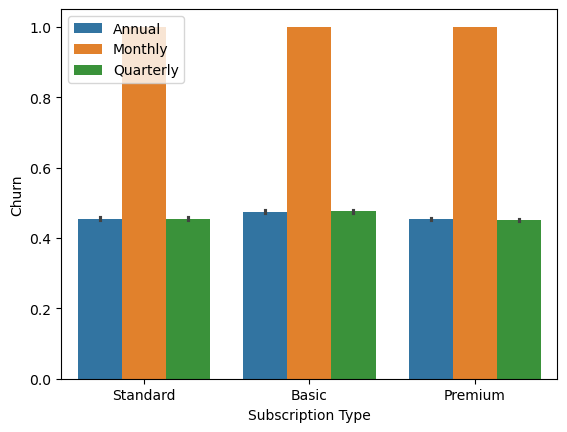

In [52]:
#comarison between Subscription type based on Contract Length
plt.Figure(figsize=(8,10))
sns.barplot(x='Subscription Type',hue='Contract Length',y='Churn',data=train)
plt.legend(loc='upper left')

<Axes: xlabel='count', ylabel='Payment Delay'>

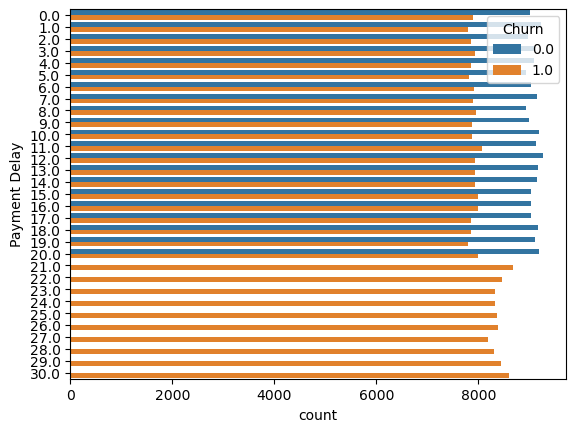

In [53]:
sns.countplot(y='Payment Delay',hue='Churn',data=train)

<Axes: xlabel='Contract Length', ylabel='count'>

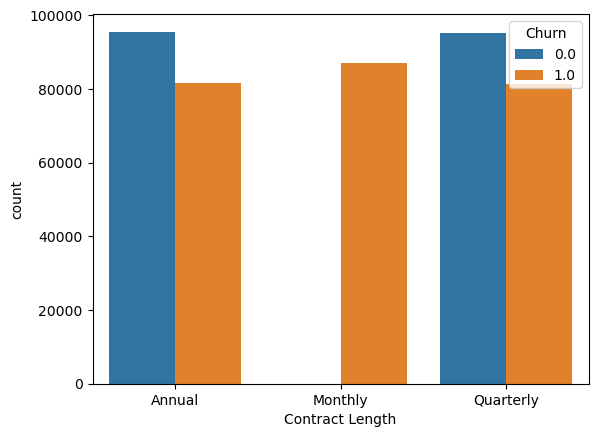

In [54]:
sns.countplot(x='Contract Length',hue='Churn',data=train)

<Axes: xlabel='Total Spend', ylabel='Subscription Type'>

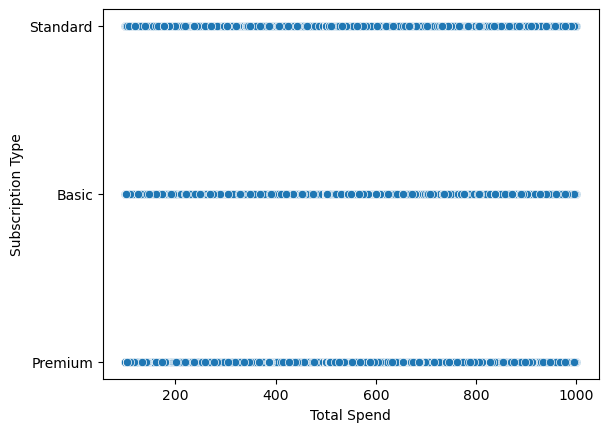

In [55]:
sns.scatterplot(x='Total Spend',y='Subscription Type',data=train)

<Axes: >

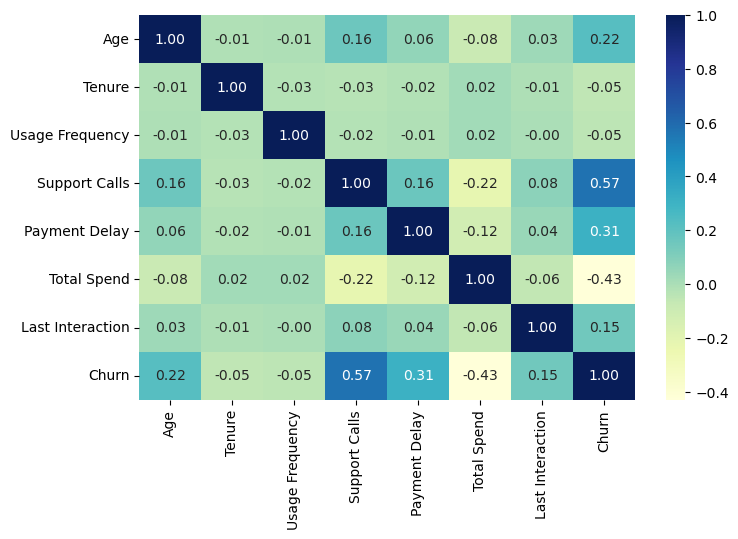

In [56]:
plt.figure(figsize=(8,5))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap="YlGnBu", fmt='.2f')

# ***Encoding***

In [57]:
X=train.drop('Churn',axis=1)
y=train['Churn']

X_train,X_val,y_train,y_val=train_test_split(X,y
                                             ,test_size=0.25,shuffle=True, random_state=100
)

In [58]:
lb=OrdinalEncoder()
cat_cols=X_train.select_dtypes('object').columns
X_train[cat_cols]=lb.fit_transform(X_train[cat_cols])
X_val[cat_cols]=lb.transform(X_val[cat_cols])
test[cat_cols]=lb.transform(test[cat_cols])

In [59]:
Scaler=StandardScaler()
num_cols=X_train.select_dtypes('number').columns
X_train[num_cols]=Scaler.fit_transform(X_train[num_cols])
X_val[num_cols]=Scaler.transform(X_val[num_cols])
test[num_cols]=Scaler.transform(test[num_cols])

In [60]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(scale_pos_weight=ratio, random_state=42)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [61]:
y_pred_val=model.predict(X_val)
print(classification_report(y_val,y_pred_val))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     47672
         1.0       1.00      1.00      1.00     62536

    accuracy                           1.00    110208
   macro avg       1.00      1.00      1.00    110208
weighted avg       1.00      1.00      1.00    110208



Confusion Matrix:


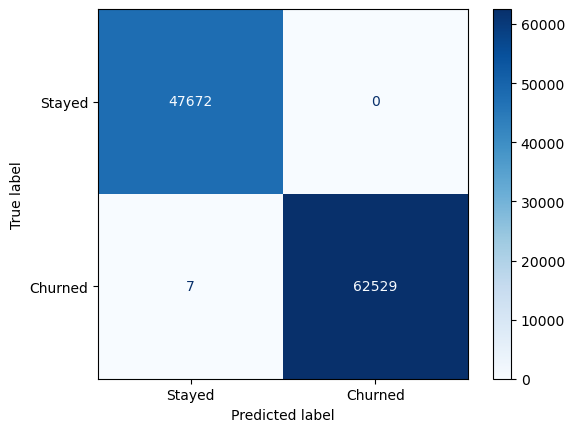

In [62]:
print("Confusion Matrix:")
cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Blues')

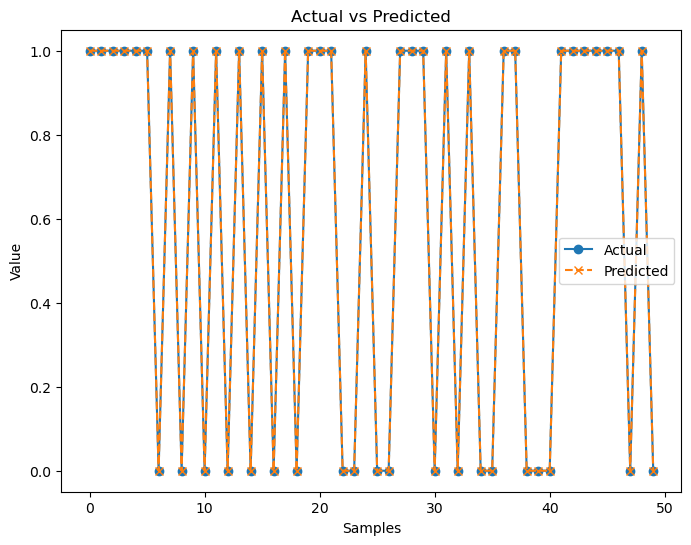

In [63]:
plt.figure(figsize=(8,6))
plt.plot(range(50),y_val[:50], label="Actual",marker='o')
plt.plot(range(50),y_pred_val[:50], label="Predicted",marker='x',linestyle='--')
plt.xlabel("Samples")
plt.ylabel("Value")
plt.title("Actual vs Predicted")
plt.legend(loc='best')
plt.legend()
plt.show()


Text(0.5, 1.0, 'ROC Curve')

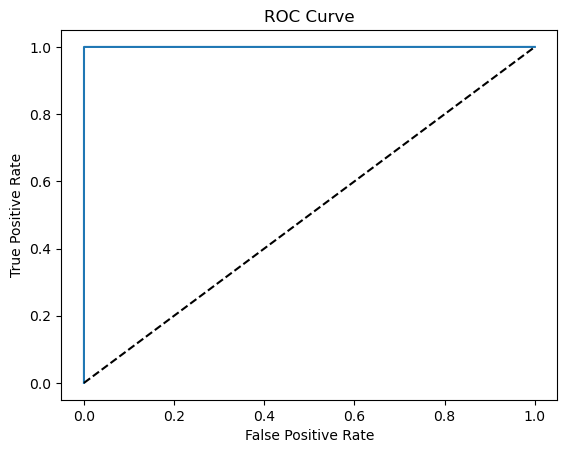

In [64]:
y_probs = model.predict_proba(X_val)[:, 1] 

fpr, tpr, thresholds = roc_curve(y_val, y_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')